In [6]:

import pandas as pd
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifParser
import yaml
from pathlib import Path
import warnings
import matplotlib.pyplot as plt

warnings.simplefilter("ignore", UserWarning)

In [7]:
BASE_PATH = Path("/Users/divya-sh/Documents")
WYCK_PATH = BASE_PATH / "gfn_data" /"structure_to_wyckoff"
DATA_PATH = BASE_PATH / "data" / "materials_dataset_v4" / "data"
# V5_PATH = BASE_PATH / "data" / "materials_dataset_v5" / "data"
V6_PATH = BASE_PATH / "data" / "materials_dataset_v6" / "data"

In [8]:
with open(WYCK_PATH / "space_groups_wyckoff.yaml") as fp:
    spg_db = yaml.safe_load(fp)
    
data_set = ["matbench_mp_e_form", "matbench_mp_gap"]
splits = ["train", "val", "test"]

LETTER_TO_IDX = {
    "a": -1, "b": -2, "c": -3, "d": -4, "e": -5, "f": -6, "g": -7, 
    "h": -8, "i": -9, "j": -10, "k": -11, "l": -12, "m": -13, "n": -14,
    "o": -15, "p": -16, "q": -17, "r": -18, "s": -19, "t": -20,
    "u": -21, "v": -22, "w": -23, "x": -24, "y": -25, "z": -26, "A":-27
} # reverse alphabetic following the international tables



In [9]:
def get_wyckoff_representation(structure:Structure):
    """analyzes a structure and then returns the Wyckoff encoded data

    Parameters
    ----------
    structure : Structure
        pymatgen structure

    Returns
    -------
    tuple
        tuple of type (spacegroup_number, wyckoff_list) where wyckoff_list is of type (element,wyckoff_id), for instance [(Li, 187), (O, 187), (O, 190)]
    """
    spg_analyzer = SpacegroupAnalyzer(structure)
    refined_structure = spg_analyzer.get_refined_structure()
    spg_analyzer = SpacegroupAnalyzer(refined_structure)
    symm_struct = spg_analyzer.get_symmetrized_structure()

    wyckoff_letters = [w[-1] for w in symm_struct.wyckoff_symbols]
    elements= [str(s[0].specie) for s in symm_struct.equivalent_sites]
    spacegroup_number = symm_struct.spacegroup.int_number
    wyckoff_ids = [spg_db[spacegroup_number]['wyckoff_positions'][LETTER_TO_IDX[wl]] for wl in wyckoff_letters]

    return spacegroup_number, [(element, wyckoff_id) for element,wyckoff_id in zip(elements,wyckoff_ids)]

matbench_mp_e_form
train
222 22
matbench_mp_e_form
val
222 22
matbench_mp_e_form
test
228 22


KeyboardInterrupt: 

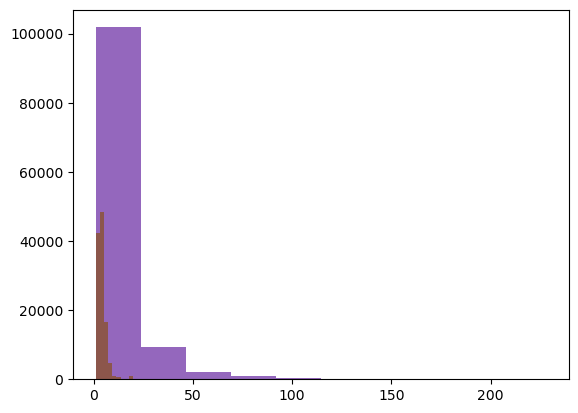

In [10]:
for data in data_set:
    counts = []
    red_count = []
    for split in splits:
        wyck = []
        df = pd.read_csv(DATA_PATH / data / f"{split}_data.csv")
        for (i, row) in list(df.iterrows()):
            struct = CifParser.from_str(row["cif"])
            struct = struct.parse_structures(primitive=False)[0]
            spg, wyck_tuples = get_wyckoff_representation(struct)
            counts.append(len(wyck_tuples))
            wyck_tuples = set(wyck_tuples)
            red_count.append(len(wyck_tuples))
            wyck_tuples = [f"({a},{b})" for a,b in wyck_tuples]
            wyck_str = "-".join(wyck_tuples)
            wyck.append(wyck_str)
        # df["Wyckoff"] = wyck
        # df.to_csv(V6_PATH / data / f"{split}_data.csv")
        print(data)
        print(split)
        plt.hist(counts)
        plt.hist(red_count)
        print(max(counts), max(red_count))
    